In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import tqdm
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torch.optim.lr_scheduler as lr_scheduler
import pandas as pd
from adao import adaoBuilder
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
pale_data = pd.read_csv('/libre/sibo.cheng/data/paleoclimate/Prior.csv')

In [4]:
pale_data

,Unnamed: 0,lon,lat,age,st_1,st_2,st_3,st_4,err_st_1,err_st_2,err_st_3,err_st_4,mtco,mtwa,err_mtco,err_mtwa
0,1,-174.375,-84.375,29100,-29.256677,-42.773607,-45.729459,-39.627318,1.877158,1.775273,1.907136,2.012002,-45.729459,-29.256677,1.907136,1.877158
1,2,-168.750,-84.375,29100,-28.864881,-42.118732,-44.938726,-39.118494,1.963732,1.830048,1.894272,2.037010,-44.938726,-28.864881,1.894272,1.963732
2,3,-163.125,-84.375,29100,-28.494024,-41.494891,-44.139167,-38.552925,2.038193,1.887006,1.929476,2.097409,-44.139167,-28.494024,1.929476,2.038193
3,4,-157.500,-84.375,29100,-28.171974,-40.995896,-43.514596,-38.090938,2.087535,1.931168,1.955416,2.139272,-43.514596,-28.171974,1.955416,2.087535
4,5,-151.875,-84.375,29100,-27.921712,-40.672860,-43.133442,-37.772990,2.103827,1.956768,1.967478,2.155209,-43.133442,-27.921712,1.967478,2.103827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1646587,1646588,157.500,90.000,49175,-47.933094,-37.417086,-6.606186,-40.941990,2.519231,2.770391,1.548714,3.096939,-47.933094,-6.606186,2.519231,1.548714
1646588,1646589,163.125,90.000,49175,-47.668873,-37.107115,-6.599521,-40.986267,2.625142,2.641540,1.624428,3.174941,-47.668873,-6.599521,2.625142,1.624428
1646589,1646590,168.750,90.000,49175,-47.423794,-36.826855,-6.580541,-41.058242,2.726810,2.498549,1.695031,3.280850,-47.423794,-6.580541,2.726810,1.695031
1646590,1646591,174.375,90.000,49175,-47.200306,-36.580564,-6.550148,-41.158900,2.821337,2.343600,1.759262,3.411595,-47.200306,-6.550148,2.821337,1.759262


In [5]:
print(pale_data.columns.tolist())

['Unnamed: 0', 'lon', 'lat', 'age', 'st_1', 'st_2', 'st_3', 'st_4', 'err_st_1', 'err_st_2', 'err_st_3', 'err_st_4', 'mtco', 'mtwa', 'err_mtco', 'err_mtwa']


In [9]:
print('number of model time steps: ', pale_data['age'].unique().shape)

number of model time steps:  (804,)


In [5]:
print(pale_data.isna().sum())

Unnamed: 0    0
lon           0
lat           0
age           0
st_1          0
st_2          0
st_3          0
st_4          0
err_st_1      0
err_st_2      0
err_st_3      0
err_st_4      0
mtco          0
mtwa          0
err_mtco      0
err_mtwa      0
dtype: int64


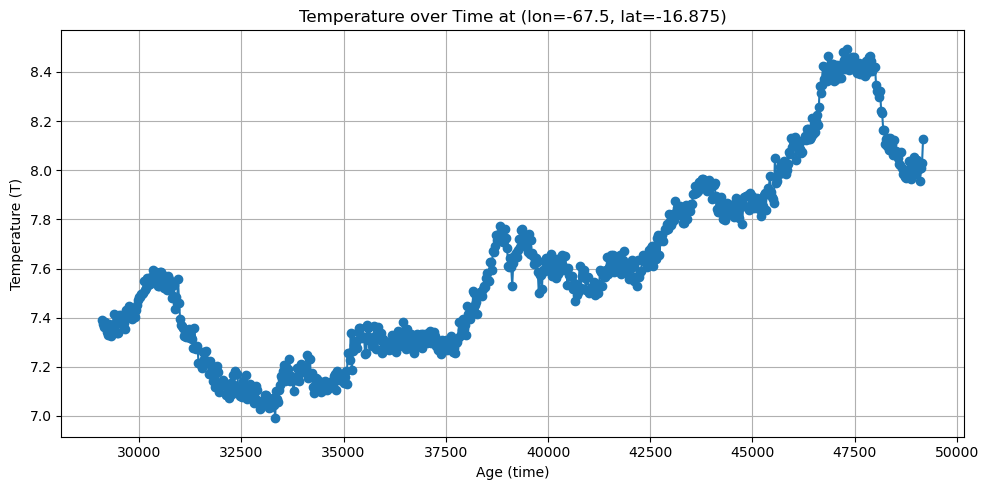

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


selected_lat = -16.875
selected_lon = -67.500

#Filter the data for that location
filtered_df = pale_data[(pale_data['lat'] == selected_lat) & (pale_data['lon'] == selected_lon)]

# Sort by age for proper plotting
filtered_df = filtered_df.sort_values(by='age')

plt.figure(figsize=(10, 5))
plt.plot(filtered_df['age'], filtered_df['st_1'], marker='o', linestyle='-')
plt.xlabel('Age (time)')
plt.ylabel('Temperature (T)')
plt.title(f'Temperature over Time at (lon={selected_lon}, lat={selected_lat})')
plt.grid(True)
plt.tight_layout()
plt.show()


Unnamed: 0    1.642497e+06
lon          -1.743750e+02
lat          -8.437500e+01
age           4.915000e+04
st_1         -2.609415e+01
st_2         -4.092090e+01
st_3         -4.551320e+01
st_4         -4.003073e+01
err_st_1      1.798276e+00
err_st_2      1.291486e+00
err_st_3      1.543348e+00
err_st_4      1.904633e+00
mtco         -4.551320e+01
mtwa         -2.609415e+01
err_mtco      1.543348e+00
err_mtwa      1.798276e+00
Name: 1642496, dtype: float64
Unnamed: 0    1.642498e+06
lon          -1.687500e+02
lat          -8.437500e+01
age           4.915000e+04
st_1         -2.540076e+01
st_2         -4.019693e+01
st_3         -4.467820e+01
st_4         -3.947767e+01
err_st_1      1.870336e+00
err_st_2      1.355741e+00
err_st_3      1.556251e+00
err_st_4      1.959608e+00
mtco         -4.467820e+01
mtwa         -2.540076e+01
err_mtco      1.556251e+00
err_mtwa      1.870336e+00
Name: 1642497, dtype: float64
Unnamed: 0    1.642499e+06
lon          -1.631250e+02
lat          -8.437500

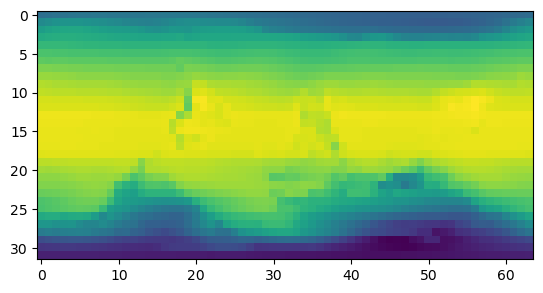

In [ ]:
#take an example time step
filtered_model = pale_data[pale_data['age'] == 49150]

def tabletoarray(df):
    unique_lons = np.sort(df['lon'].unique())
    unique_lats = np.sort(df['lat'].unique())

    #create empty 2D arrays
    value_grid = np.full((len(unique_lats), len(unique_lons)), np.nan)
    error_grid = np.full((len(unique_lats), len(unique_lons)), np.nan)

    # Fill the grids
    for _, row in df.iterrows():
        print(row)
        lon_idx = np.where(unique_lons == row['lon'])[0][0]
        lat_idx = np.where(unique_lats == row['lat'])[0][0]
        value_grid[lat_idx, lon_idx] = row['st_1']
        error_grid[lat_idx, lon_idx] = row['err_st_1']
    
    return value_grid,error_grid

value_model,error_model = tabletoarray(filtered_model)

value_model = np.nan_to_num(value_model, nan=0.0)
error_model = np.nan_to_num(error_model, nan=0.0)
plt.imshow(value_model)






In [14]:
obs = pd.read_csv('/libre/sibo.cheng/data/paleoclimate/Observation.csv')

In [18]:
print(obs.isna().sum())

Unnamed: 0               0
siteID                   0
sampleID                 0
age_mean                 0
age_youngest             0
age_oldest               0
count_type               0
age                      0
mtco                     0
sse_mtco                 0
mtwa                     0
sse_mtwa                 0
alpha                    0
sse_alpha                0
Tmean                    0
sse_Tmean                0
site_name                0
latitude                 0
longitude                0
elevation                0
site_type                0
source                   0
references               0
palaeo_mtgr              0
modern_mtgr              0
palaeo_CO2               0
modern_CO2               0
mi_found                 0
mi_corrected             0
alpha_corrected          0
mi_upper_found           0
mi_upper_corrected       0
alpha_upper_corrected    0
mi_lower_found           0
mi_lower_corrected       0
alpha_lower_corrected    0
sse_alpha_corrected      0
d

Unnamed: 0                                                             272
siteID                                                                   1
sampleID                                                                32
age_mean                                                             49424
age_youngest                                                         48286
age_oldest                                                           50512
count_type                                                           COUNT
age                                                                  49150
mtco                                                             -6.044488
sse_mtco                                                          1.720434
mtwa                                                             19.932759
sse_mtwa                                                           1.38354
alpha                                                             0.562272
sse_alpha                

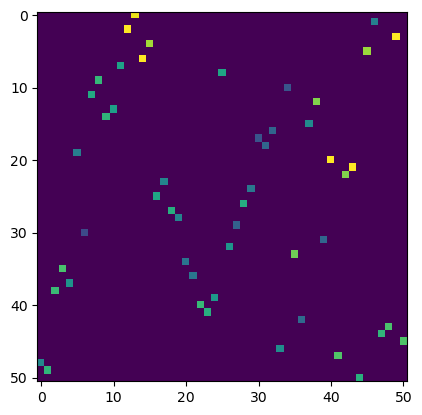

In [ ]:
#take an example time step
filtered_obs = obs[obs['age'] == 49150]

def obstoarray(df):
    unique_lons = np.sort(df['longitude'].unique())
    unique_lats = np.sort(df['latitude'].unique())

    value_grid = np.full((len(unique_lats), len(unique_lons)), np.nan)
    error_grid = np.full((len(unique_lats), len(unique_lons)), np.nan)

    #  Fill the grids
    for _, row in df.iterrows():
        print(row)
        lon_idx = np.where(unique_lons == row['longitude'])[0][0]
        lat_idx = np.where(unique_lats == row['latitude'])[0][0]
        value_grid[lat_idx, lon_idx] = row['alpha']
        error_grid[lat_idx, lon_idx] = row['sse_alpha']
    
    return value_grid,error_grid


value_model,error_model = obstoarray(filtered_obs)

value_model = np.nan_to_num(value_model, nan=0.0)
error_model = np.nan_to_num(error_model, nan=0.0)
plt.imshow(value_model)